## Install Packages

In [ ]:
!pip install pandas
!pip install numpy
!pip install scikit-learn
!pip install matplotlib
!pip install  seaborn
!pip install  jupyter

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.4/12.4 MB 149.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 76.7/76.7 kB 8.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 59.8/59.8 kB 7.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 95.4 MB/s eta 0:00:00



## Fetch Data

In [ ]:
import kagglehub
import shutil


# Download latest version
fitness_premove = kagglehub.dataset_download("jijagallery/fitlife-health-and-fitness-tracking-dataset")

print("Path to dataset files before moving:", fitness_premove)

#!mv /root/.cache/kagglehub/datasets/jijagallery/fitlife-health-and-fitness-tracking-dataset/versions/1/health_fitness_dataset.csv /content
!mv /kaggle/input/fitlife-health-and-fitness-tracking-dataset /content

#fitness = "/content/health_fitness_dataset.csv"
#fitness = "/root/.cache/kagglehub/datasets/jijagallery/fitlife-health-and-fitness-tracking-dataset/versions/1"
print("Path to dataset files after moving:", fitness)

Path to dataset files before moving: /root/.cache/kagglehub/datasets/jijagallery/fitlife-health-and-fitness-tracking-dataset/versions/1
mv: cannot stat '/kaggle/input/fitlife-health-and-fitness-tracking-dataset': No such file or directory
Path to dataset files after moving: /root/.cache/kagglehub/datasets/jijagallery/fitlife-health-and-fitness-tracking-dataset/versions/1


## Clean Data

Create dataframe using Pandas by dropping misc. columns.

In [ ]:
import pandas as pd

fitness_df_pre = pd.read_csv("/content/health_fitness_dataset.csv")

In [ ]:
#before
print(fitness_df_pre.columns)

#after
# fitness_df = fitness_df_pre.drop(['participant_id', 'date', 'height_cm', 'weight_kg', 'intensity', 'calories_burned', 'avg_heart_rate', 'hours_sleep', 'daily_steps', 'hydration_level', 'bmi', 'resting_heart_rate',
#        'blood_pressure_systolic', 'blood_pressure_diastolic',
#        'health_condition', 'smoking_status', 'fitness_level' ], axis=1)

fitness_df = fitness_df_pre.drop(['participant_id', 'date', 'height_cm', 'weight_kg', 'intensity', 'calories_burned', 'hours_sleep', 'daily_steps', 'hydration_level', 'bmi',
       'health_condition', 'smoking_status', 'fitness_level' ], axis=1)

print(fitness_df.shape)
print(fitness_df.columns)

Index(['participant_id', 'date', 'age', 'gender', 'height_cm', 'weight_kg',
       'activity_type', 'duration_minutes', 'intensity', 'calories_burned',
       'avg_heart_rate', 'hours_sleep', 'stress_level', 'daily_steps',
       'hydration_level', 'bmi', 'resting_heart_rate',
       'blood_pressure_systolic', 'blood_pressure_diastolic',
       'health_condition', 'smoking_status', 'fitness_level'],
      dtype='object')
(687701, 9)
Index(['age', 'gender', 'activity_type', 'duration_minutes', 'avg_heart_rate',
       'stress_level', 'resting_heart_rate', 'blood_pressure_systolic',
       'blood_pressure_diastolic'],
      dtype='object')


In [ ]:
fitness_df.head()


,age,gender,activity_type,duration_minutes,avg_heart_rate,stress_level,resting_heart_rate,blood_pressure_systolic,blood_pressure_diastolic
0,56,F,Dancing,41,103,3,69.5,110.7,72.9
1,56,F,Swimming,28,102,7,69.5,110.7,72.9
2,56,F,Swimming,21,126,7,69.5,110.7,72.9
3,56,F,Weight Training,99,141,8,69.5,110.7,72.9
4,56,F,Swimming,100,112,1,69.5,110.7,72.9


## Data Validation

The following code is a basic summary of our dataset so far.

In [ ]:
import matplotlib.pyplot as plt

print("Dataframe description: ")
print(fitness_df.describe())
print(fitness_df.describe(include='object'))
print("___________________________________________________________________ ")

print("Dataframe info: ")
print(fitness_df.info())
print("___________________________________________________________________ ")




Dataframe description: 
                 age  duration_minutes  avg_heart_rate   stress_level  \
count  687701.000000     687701.000000   687701.000000  687701.000000   
mean       41.658602         70.011671      131.454165       5.252389   
std        13.581770         29.147251       17.814744       2.770029   
min        18.000000         20.000000       82.000000       1.000000   
25%        30.000000         45.000000      118.000000       3.000000   
50%        42.000000         70.000000      130.000000       5.000000   
75%        53.000000         95.000000      144.000000       8.000000   
max        64.000000        120.000000      206.000000      10.000000   

       resting_heart_rate  blood_pressure_systolic  blood_pressure_diastolic  
count       687701.000000            687701.000000             687701.000000  
mean            70.010547               120.001260                 80.188079  
std              5.074563                10.008917                  8.239418  
mi

The following performs qualitivate data analysis to see the distribution of gender and activity type. The goal is to visually confirm that there is an even distribution, and no imbalances in our dataset that could lead to biases.

First, we can see the ratios of each gender anda activity_type, then visualize plots for each column.

In [ ]:

print("Dataframe age and stress distribution: ")
print(f"Age mean: {fitness_df['age'].mean()}")
print(f"Age std: {fitness_df['age'].std()}")
print(f"Stress level std: {fitness_df['stress_level'].std()}")
print("___________________________________________________________________")

print("Specific ratios of gender: ")

rows = fitness_df.shape[0]
f_age_ratio = fitness_df['gender'].value_counts()['F']/rows
m_age_ratio = fitness_df['gender'].value_counts()['M']/rows
o_age_ratio = fitness_df['gender'].value_counts()['Other']/rows
print(f"Female: {f_age_ratio}")
print(f"Male: {m_age_ratio}")
print(f"Other: {o_age_ratio}")
print("  ")

print("Specific ratios of activity type: ")

rows = fitness_df.shape[0]
activity_types = fitness_df['activity_type'].unique()
actvity_type_value_counts = fitness_df['activity_type'].value_counts()
for activity in activity_types:
  activity_ratio = actvity_type_value_counts[activity]/rows
  print(f"{activity}: {activity_ratio}" )



Dataframe age and stress distribution: 
Age mean: 41.65860163065053
Age std: 13.581770006251082
Stress level std: 2.770028887637193
___________________________________________________________________
Specific ratios of gender: 
Female: 0.4927373960485734
Male: 0.48570963252925325
Other: 0.0215529714221733
  
Specific ratios of activity type: 
Dancing: 0.10061494748444455
Swimming: 0.09892671378985926
Weight Training: 0.10129547579544017
HIIT: 0.10088105150348771
Running: 0.09763690906367738
Walking: 0.09899214920437807
Tennis: 0.09965522807150201
Basketball: 0.09965959043246993
Yoga: 0.10173171189223223
Cycling: 0.1006062227625087


We can visualize the distributions of each column, to ensure our dataset is appropriate. From the below graphs, we can visually confirm that we do have an even distribution:



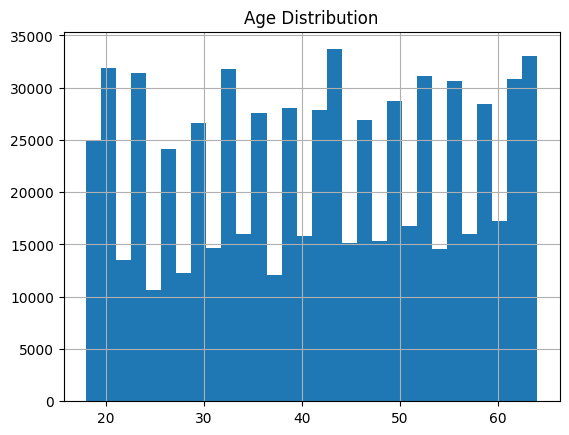

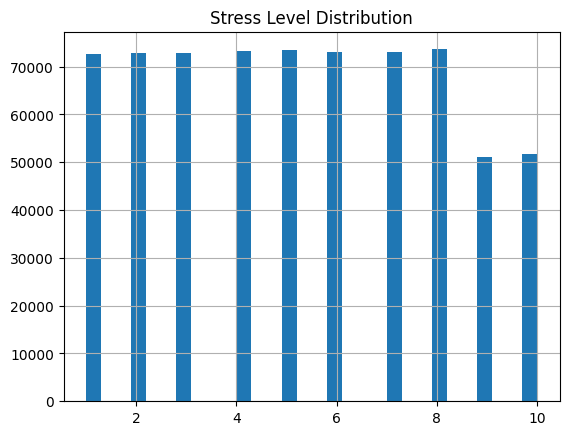

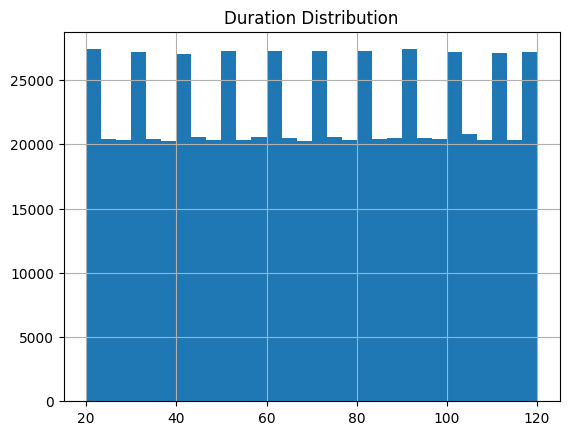

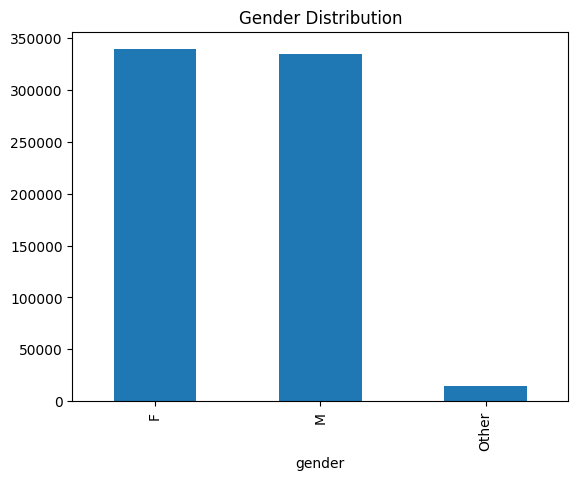

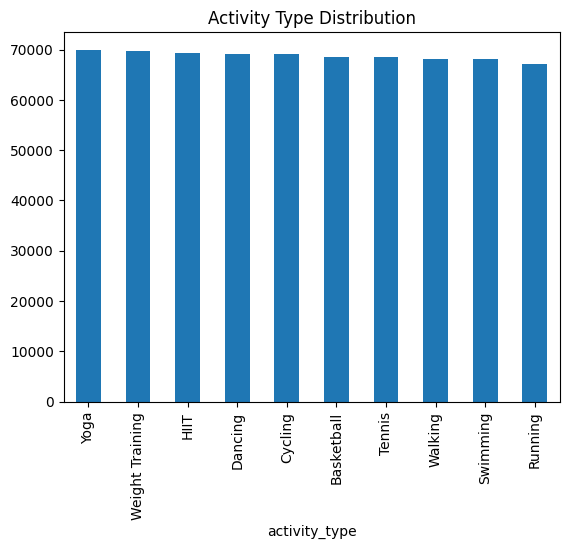

In [ ]:
fitness_df['age'].hist(bins=30)
plt.title('Age Distribution')
plt.show()
print("  ")

fitness_df['stress_level'].hist(bins=30)
plt.title('Stress Level Distribution')
plt.show()
print("  ")

fitness_df['duration_minutes'].hist(bins=30)
plt.title('Duration Distribution')
plt.show()
print("  ")

fitness_df['gender'].value_counts().plot(kind='bar')
plt.title('Gender Distribution')
plt.show()
print("  ")

fitness_df['activity_type'].value_counts().plot(kind='bar')
plt.title('Activity Type Distribution')
plt.show()
print("  ")

Since we will be outputting the best excercise and frequency based on age and gender, it's important to cross check and ensure that we have even distributions across these factors. We will crosscheck using Pandas crosstab.

In [ ]:
print("Gender and Activiy type: ")
print(" ")
print(pd.crosstab(fitness_df['gender'], fitness_df['activity_type']))
print(" ")
print("___________________________________________________________________")
print(" ")

fitness_df['age_group'] = pd.cut(fitness_df['age'], bins=[0, 20, 30, 40, 50, 60, 100],
                          labels=['<20', '20-29', '30-39', '40-49', '50-59', '60+'])

print("Age and Activiy type: ")
print(" ")
print(pd.crosstab(fitness_df['age_group'], fitness_df['activity_type']))
print(" ")
print("___________________________________________________________________")
print(" ")

print("Age and Gender: ")
print(" ")
print(pd.crosstab(fitness_df['age_group'], fitness_df['gender']))
print(" ")
print("___________________________________________________________________")
print(" ")

print("Age, Gender, Activity type: ")
print(" ")
print(pd.crosstab([fitness_df['gender'], fitness_df['age_group']], fitness_df['activity_type']))
print(" ")

Gender and Activiy type: 
 
activity_type  Basketball  Cycling  Dancing   HIIT  Running  Swimming  Tennis  \
gender                                                                          
F                   34018    34558    33932  34132    32811     33397   33660   
M                   33130    33161    33789  33877    32814     33353   33311   
Other                1388     1468     1472   1367     1520      1282    1562   

activity_type  Walking  Weight Training   Yoga  
gender                                          
F                33825            34079  34444  
M                32863            33972  33753  
Other             1389             1610   1764  
 
___________________________________________________________________
 
Age and Activiy type: 
 
activity_type  Basketball  Cycling  Dancing   HIIT  Running  Swimming  Tennis  \
age_group                                                                       
<20                  4004     4199     3955   3825     4037   

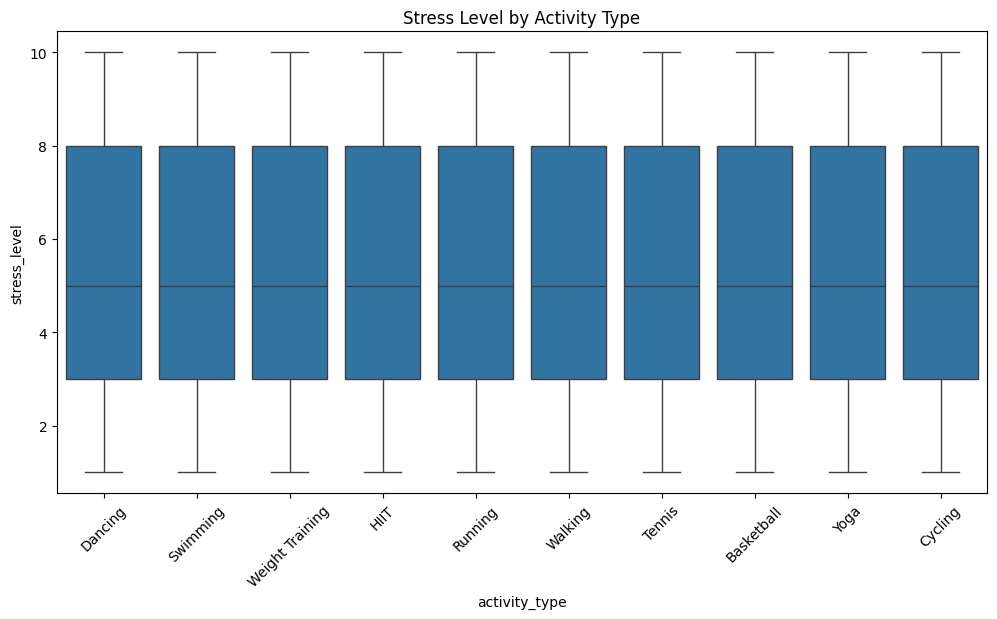

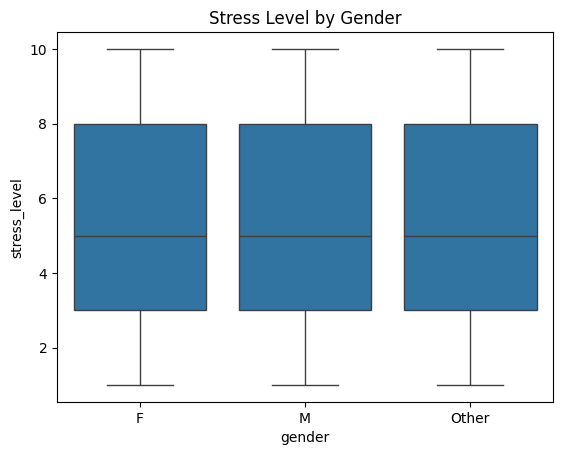

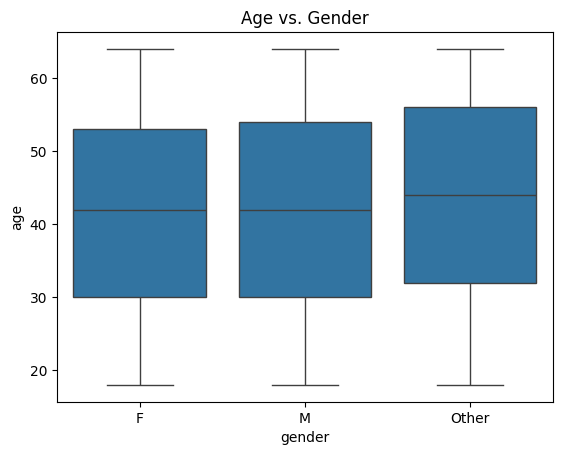

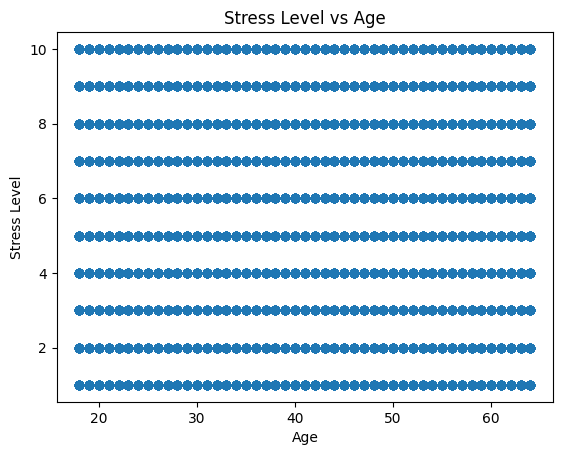

In [ ]:
import seaborn as sns

plt.figure(figsize=(12, 6))
sns.boxplot(data=fitness_df, x='activity_type', y='stress_level')
plt.xticks(rotation=45)
plt.title('Stress Level by Activity Type')
plt.show()

sns.boxplot(data=fitness_df, x='gender', y='stress_level')
plt.title('Stress Level by Gender')
plt.show()

sns.boxplot(data=fitness_df, x='gender', y='age')
plt.title('Age vs. Gender')
plt.show()


plt.scatter(fitness_df['age'], fitness_df['stress_level'], alpha=0.1)
plt.xlabel('Age')
plt.ylabel('Stress Level')
plt.title('Stress Level vs Age')
plt.show()

In [ ]:
fitness_df["age"].describe()

,age
count,687701.000000
mean,41.658602
std,13.581770
min,18.000000
25%,30.000000
50%,42.000000
75%,53.000000
max,64.000000


Given that the min age is 18 and the max is 64, our data seems to have valid distribution when considering more than one factor.

We are able to move on with feauture engineering.

## Feature engineering

Before we begin building our model and training, we need to one-hot encode our qualitative data.

First, let's see what we need to work with.

In [ ]:
fitness_df.head()

,age,gender,activity_type,duration_minutes,avg_heart_rate,stress_level,resting_heart_rate,blood_pressure_systolic,blood_pressure_diastolic,age_group
0,56,F,Dancing,41,103,3,69.5,110.7,72.9,50-59
1,56,F,Swimming,28,102,7,69.5,110.7,72.9,50-59
2,56,F,Swimming,21,126,7,69.5,110.7,72.9,50-59
3,56,F,Weight Training,99,141,8,69.5,110.7,72.9,50-59
4,56,F,Swimming,100,112,1,69.5,110.7,72.9,50-59


drop other gender column

In [ ]:
fitness_df = fitness_df[fitness_df['gender'] != 'Other']


In [ ]:
# One hot encode activity type and gender
df_encoded = pd.get_dummies(fitness_df, columns=['activity_type', 'gender'], prefix=['at', 'g'])
df_encoded.head()

,age,duration_minutes,avg_heart_rate,stress_level,resting_heart_rate,blood_pressure_systolic,blood_pressure_diastolic,age_group,at_Basketball,at_Cycling,at_Dancing,at_HIIT,at_Running,at_Swimming,at_Tennis,at_Walking,at_Weight Training,at_Yoga,g_F,g_M
0,56,41,103,3,69.5,110.7,72.9,50-59,False,False,True,False,False,False,False,False,False,False,True,False
1,56,28,102,7,69.5,110.7,72.9,50-59,False,False,False,False,False,True,False,False,False,False,True,False
2,56,21,126,7,69.5,110.7,72.9,50-59,False,False,False,False,False,True,False,False,False,False,True,False
3,56,99,141,8,69.5,110.7,72.9,50-59,False,False,False,False,False,False,False,False,True,False,True,False
4,56,100,112,1,69.5,110.7,72.9,50-59,False,False,False,False,False,True,False,False,False,False,True,False


In [ ]:
# Drop extra age group column
df_encoded = df_encoded.drop(["age_group"], axis = 1)
df_encoded.head()


,age,duration_minutes,avg_heart_rate,stress_level,resting_heart_rate,blood_pressure_systolic,blood_pressure_diastolic,at_Basketball,at_Cycling,at_Dancing,at_HIIT,at_Running,at_Swimming,at_Tennis,at_Walking,at_Weight Training,at_Yoga,g_F,g_M
0,56,41,103,3,69.5,110.7,72.9,False,False,True,False,False,False,False,False,False,False,True,False
1,56,28,102,7,69.5,110.7,72.9,False,False,False,False,False,True,False,False,False,False,True,False
2,56,21,126,7,69.5,110.7,72.9,False,False,False,False,False,True,False,False,False,False,True,False
3,56,99,141,8,69.5,110.7,72.9,False,False,False,False,False,False,False,False,True,False,True,False
4,56,100,112,1,69.5,110.7,72.9,False,False,False,False,False,True,False,False,False,False,True,False


# Adding variance

In [ ]:
# Add small noise
import numpy as np

df_encoded["age"] = df_encoded["age"] + np.random.normal(0, 2.5, df_encoded.shape[0])

# Optional mild non-linear trend: stress increases slightly after midlife
df_encoded["age_adj"] = df_encoded["age"]


In [ ]:
# Add Gaussian jitter
df_encoded["stress_level"] = df_encoded["stress_level"] + np.random.normal(0, 0.4, df_encoded.shape[0])

# Optionally clip to valid range if stress goes 1–10
df_encoded["stress_level"] = df_encoded["stress_level"].clip(1, 10)


In [ ]:
gender_effects = {
    "g_F": 0.1,
    "g_M": -0.1,
    "g_Other": 0.0
}

for col, effect in gender_effects.items():
    if col in df_encoded.columns:
        df_encoded["stress_level"] += df_encoded[col] * effect


In [ ]:
activity_effects = {
    # Low intensity
    "at_Yoga": -0.20,
    "at_Walking": -0.20,
    "at_Swimming": -0.25,

    # Moderate intensity
    "at_Cycling": -0.30,
    "at_Dancing": -0.30,
    "at_Weight Training": -0.35,

    # High intensity
    "at_Running": -0.50,
    "at_HIIT": -0.60,
    "at_Basketball": -0.45,
    "at_Tennis": -0.45,
}

# Apply effects
for col, effect in activity_effects.items():
    if col in df_encoded.columns:
        df_encoded["stress_level"] += df_encoded[col] * effect


In [ ]:
df_encoded.head()

,age,duration_minutes,avg_heart_rate,stress_level,resting_heart_rate,blood_pressure_systolic,blood_pressure_diastolic,at_Basketball,at_Cycling,at_Dancing,at_HIIT,at_Running,at_Swimming,at_Tennis,at_Walking,at_Weight Training,at_Yoga,g_F,g_M,age_adj
0,56.319525,41,103,3.240071,69.5,110.7,72.9,False,False,True,False,False,False,False,False,False,False,True,False,56.319525
1,55.869700,28,102,6.906949,69.5,110.7,72.9,False,False,False,False,False,True,False,False,False,False,True,False,55.869700
2,57.107901,21,126,5.908752,69.5,110.7,72.9,False,False,False,False,False,True,False,False,False,False,True,False,57.107901
3,53.744864,99,141,8.378073,69.5,110.7,72.9,False,False,False,False,False,False,False,False,True,False,True,False,53.744864
4,58.166235,100,112,0.850000,69.5,110.7,72.9,False,False,False,False,False,True,False,False,False,False,True,False,58.166235


Train/test split

In [ ]:
from sklearn.model_selection import train_test_split

# Convert to 3 classes: Low (1-3), Medium (4-7), High (8-10)
# 1) After  all noise/effects:
df_encoded["stress_level"] = df_encoded["stress_level"].clip(1, 10)

# 2) Then safely bin into 3 classes
df_encoded["stress_category"] = pd.cut(
    df_encoded["stress_level"],
    bins=[1, 3, 7, 10],
    labels=["Low", "Medium", "High"],
    include_lowest=True
)


X = df_encoded[["age", "duration_minutes", "at_Basketball", "at_Cycling", "at_Dancing", "at_HIIT",
                "at_Running", "at_Swimming", "at_Tennis", "at_Walking",
                "at_Weight Training", "at_Yoga", "g_F", "g_M", "avg_heart_rate",
                "resting_heart_rate", "blood_pressure_systolic",
                "blood_pressure_diastolic"]]

y = df_encoded['stress_category']

# 80/20 train/test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,      # 20% for testing
    random_state=42
)


In [ ]:
import pandas as pd
from sklearn.feature_selection import mutual_info_classif



mi = mutual_info_classif(df_encoded[["age"]] , y, discrete_features=False, random_state=0)
print("Mutual information AGE and STRESS:", mi)

mi = mutual_info_classif(df_encoded[["duration_minutes"]] , y, discrete_features=False, random_state=0)
print("Mutual information STRESS and duration_minutes:", mi)

mi = mutual_info_classif(df_encoded[["at_Basketball"]] , y, discrete_features=False, random_state=0)
print("Mutual information STRESS and at_Basketball:", mi)

mi = mutual_info_classif(df_encoded[["at_Cycling"]] , y, discrete_features=False, random_state=0)
print("Mutual information STRESS and at_Cycling:", mi)

mi = mutual_info_classif(df_encoded[["at_Dancing"]] , y, discrete_features=False, random_state=0)
print("Mutual information STRESS and at_Dancing:", mi)

mi = mutual_info_classif(df_encoded[["at_HIIT"]] , y, discrete_features=False, random_state=0)
print("Mutual information STRESS and at_HIIT:", mi)

mi = mutual_info_classif(df_encoded[["at_Running"]] , y, discrete_features=False, random_state=0)
print("Mutual information STRESS and at_Running:", mi)

mi = mutual_info_classif(df_encoded[["at_Swimming"]] , y, discrete_features=False, random_state=0)
print("Mutual information STRESS and at_Swimming:", mi)

mi = mutual_info_classif(df_encoded[["at_Tennis"]] , y, discrete_features=False, random_state=0)
print("Mutual information STRESS and at_Tennis:", mi)

mi = mutual_info_classif(df_encoded[["at_Walking"]] , y, discrete_features=False, random_state=0)
print("Mutual information STRESS and at_Walking:", mi)

mi = mutual_info_classif(df_encoded[["at_Weight Training"]] , y, discrete_features=False, random_state=0)
print("Mutual information STRESS and at_Weight Training:", mi)

mi = mutual_info_classif(df_encoded[["at_Yoga"]] , y, discrete_features=False, random_state=0)
print("Mutual information STRESS and at_Yoga:", mi)

mi = mutual_info_classif(df_encoded[["g_F"]] , y, discrete_features=False, random_state=0)
print("Mutual information STRESS and g_F:", mi)

mi = mutual_info_classif(df_encoded[["g_M"]] , y, discrete_features=False, random_state=0)
print("Mutual information STRESS and g_M:", mi)

mi = mutual_info_classif(df_encoded[["avg_heart_rate"]] , y, discrete_features=False, random_state=0)
print("Mutual information STRESS and avg_heart_rate:", mi)

mi = mutual_info_classif(df_encoded[["resting_heart_rate"]] , y, discrete_features=False, random_state=0)
print("Mutual information STRESS and resting_heart_rate:", mi)

mi = mutual_info_classif(df_encoded[["blood_pressure_systolic"]] , y, discrete_features=False, random_state=0)
print("Mutual information STRESS and blood_pressure_systolic:", mi)

mi = mutual_info_classif(df_encoded[["blood_pressure_diastolic"]] , y, discrete_features=False, random_state=0)
print("Mutual information STRESS and blood_pressure_diastolic:", mi)

Mutual information AGE and STRESS: [0.00013389]
Mutual information STRESS and duration_minutes: [0]
Mutual information STRESS and at_Basketball: [0.00234282]
Mutual information STRESS and at_Cycling: [0.00170966]
Mutual information STRESS and at_Dancing: [0.0020008]
Mutual information STRESS and at_HIIT: [0.00261349]
Mutual information STRESS and at_Running: [0.00197639]
Mutual information STRESS and at_Swimming: [0.00127735]
Mutual information STRESS and at_Tennis: [0.00149576]
Mutual information STRESS and at_Walking: [0.00195012]
Mutual information STRESS and at_Weight Training: [0.00165852]
Mutual information STRESS and at_Yoga: [0.00285419]
Mutual information STRESS and g_F: [0.04018962]
Mutual information STRESS and g_M: [0.03928525]
Mutual information STRESS and avg_heart_rate: [2.28168835e-05]
Mutual information STRESS and resting_heart_rate: [0.00024087]
Mutual information STRESS and blood_pressure_systolic: [0.00054243]
Mutual information STRESS and blood_pressure_diastolic: 

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.feature_selection import mutual_info_classif


y = df_encoded["stress_level"].astype("category").cat.codes

mi = mutual_info_classif(X, y, discrete_features=False, random_state=0)

mi_series = pd.Series(mi, index=X.columns)

# Plot
plt.figure(figsize=(8,5))
mi_series.sort_values().plot.barh()
plt.title("Mutual Information with Stress Level")
plt.xlabel("MI Score")
plt.ylabel("Features")
plt.tight_layout()
plt.show()


Class counts:
class
Low       204026
Medium    286849
High      182004
Name: count, dtype: int64

Class percentages (%):
class
Low       30.32
Medium    42.63
High      27.05
Name: proportion, dtype: float64


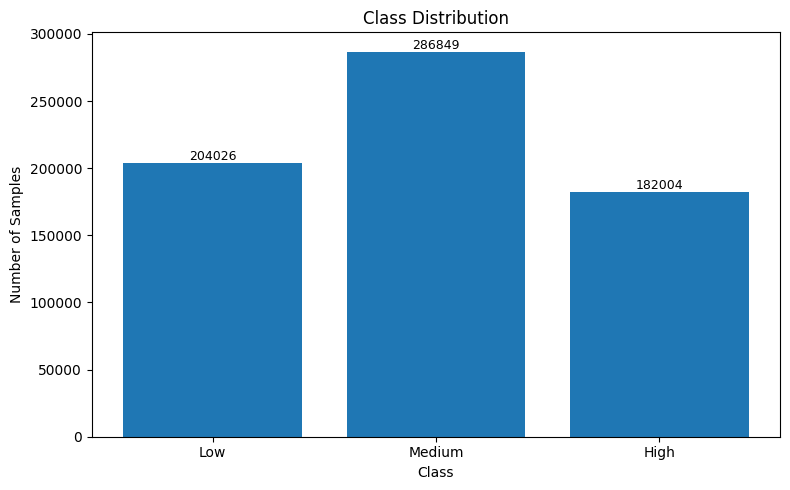

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ----------------------------------------
# ASSUMPTION: you already have `y` or `y_encoded`
# Replace `y` below with your label variable
# ----------------------------------------

# If y is not a pandas Series, convert it
y_series = pd.Series(y, name="class")

# Compute counts and percentages
class_counts = y_series.value_counts().sort_index()
class_percent = y_series.value_counts(normalize=True).sort_index() * 100

print("Class counts:")
print(class_counts)
print("\nClass percentages (%):")
print(class_percent.round(2))

# ----------------------------------------
# Visualization
# ----------------------------------------
plt.figure(figsize=(8, 5))

# Bar plot
plt.bar(class_counts.index.astype(str), class_counts.values)

# Add counts on top of bars
for idx, (cls, cnt) in enumerate(class_counts.items()):
    plt.text(
        idx, cnt, str(cnt),
        ha='center', va='bottom', fontsize=9
    )

plt.title("Class Distribution")
plt.xlabel("Class")
plt.ylabel("Number of Samples")
plt.tight_layout()
plt.show()


##  Classifiers

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, confusion_matrix
from sklearn.ensemble import RandomForestClassifier

X_train_df = pd.DataFrame(X_train, columns=X.columns)
X_test_df = pd.DataFrame(X_test, columns=X.columns)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_df)
X_test_scaled = scaler.transform(X_test_df)




## Random Forest Training

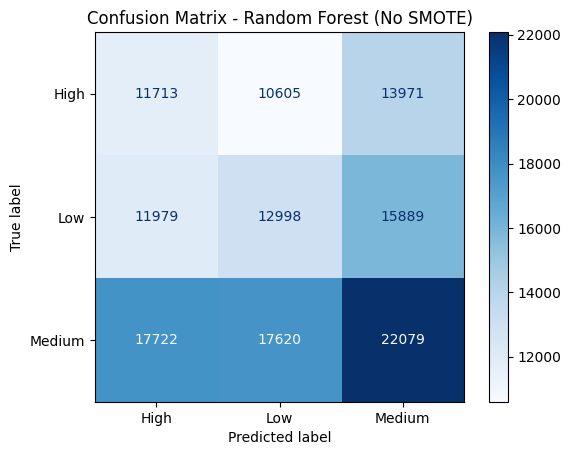

In [ ]:
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn.ensemble import RandomForestClassifier
import matplotlib.pyplot as plt

# Encode labels (same as before)
le = LabelEncoder()
y_train_encoded = le.fit_transform(y_train)
y_test_encoded = le.transform(y_test)

# Train model WITHOUT SMOTE
rf = RandomForestClassifier(
    class_weight='balanced',
    random_state=42,
    n_estimators=200,         # more stable forest
    max_depth=20,             # prevents overfitting
    min_samples_split=5,      # smoother trees
    min_samples_leaf=2,       # less variance
    max_features='sqrt'       # still recommended
)

rf.fit(X_train, y_train_encoded)

# Predict and decode back to original labels
y_pred_encoded = rf.predict(X_test)
y_pred = le.inverse_transform(y_pred_encoded)

# Confusion matrix
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=le.classes_)
disp.plot(cmap='Blues')

plt.title('Confusion Matrix - Random Forest (No SMOTE)')
plt.show()


In [ ]:
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

print(classification_report(y_test, y_pred))


              precision    recall  f1-score   support

        High       0.28      0.32      0.30     36289
         Low       0.32      0.32      0.32     40866
      Medium       0.43      0.38      0.40     57421

    accuracy                           0.35    134576
   macro avg       0.34      0.34      0.34    134576
weighted avg       0.35      0.35      0.35    134576



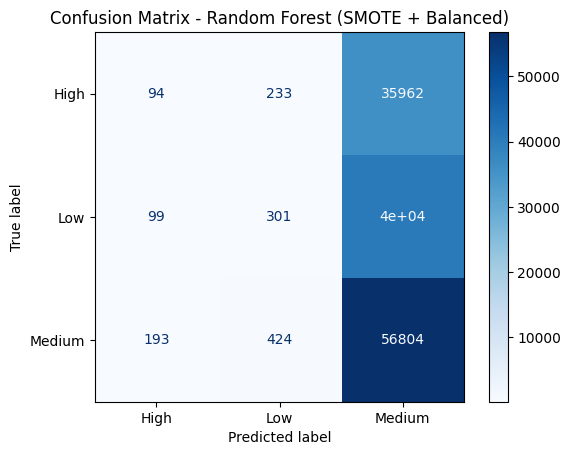

In [ ]:
from sklearn.preprocessing import LabelEncoder
from imblearn.over_sampling import SMOTE

from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# Before SMOTE - encode labels
le = LabelEncoder()
y_train_encoded = le.fit_transform(y_train)

# Apply SMOTE
X_res, y_res = SMOTE(random_state=42).fit_resample(X_train, y_train_encoded)

# Train model
rf_smote = RandomForestClassifier(class_weight='balanced',
    random_state=42,
    n_estimators=200,         # more stable forest
    max_depth=20,             # prevents overfitting
    min_samples_split=5,      # smoother trees
    min_samples_leaf=2,       # less variance
    max_features='sqrt'       # still recommended
)

rf_smote.fit(X_res, y_res)

# Predict and decode back to original labels
y_pred_encoded = rf_smote.predict(X_test)
y_pred_rf_smote = le.inverse_transform(y_pred_encoded)

# Now create confusion matrix
cm = confusion_matrix(y_test, y_pred_rf_smote)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=le.classes_)
disp.plot(cmap='Blues')
plt.title('Confusion Matrix - Random Forest (SMOTE + Balanced)')
plt.show()

In [ ]:
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

print(classification_report(y_test, y_pred_rf_smote))


              precision    recall  f1-score   support

        High       0.24      0.00      0.01     36289
         Low       0.31      0.01      0.01     40866
      Medium       0.43      0.99      0.60     57421

    accuracy                           0.43    134576
   macro avg       0.33      0.33      0.21    134576
weighted avg       0.34      0.43      0.26    134576



Gradient Boosting

              precision    recall  f1-score   support

        High       0.21      0.00      0.00     36289
         Low       0.20      0.00      0.00     40866
      Medium       0.43      1.00      0.60     57421

    accuracy                           0.43    134576
   macro avg       0.28      0.33      0.20    134576
weighted avg       0.30      0.43      0.26    134576



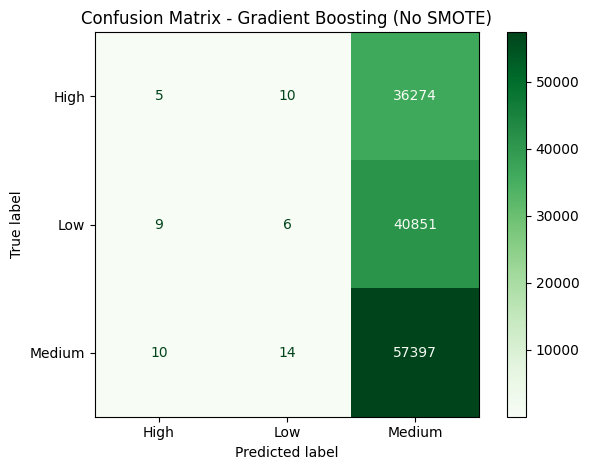


Confusion Matrix:
[[    5    10 36274]
 [    9     6 40851]
 [   10    14 57397]]

Labels order: ['High' 'Low' 'Medium']


In [ ]:
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Encode labels
le = LabelEncoder()
y_train_encoded = le.fit_transform(y_train)
y_test_encoded = le.transform(y_test)

# Train Gradient Boosting WITHOUT SMOTE
gb = GradientBoostingClassifier(random_state=42,
                                n_estimators=200,
                                learning_rate=0.05,
                                max_depth=3,
                                subsample=0.8,
                                min_samples_split=5,
                                min_samples_leaf=2 )

gb.fit(X_train, y_train_encoded)

# Predict and decode back to original labels
y_pred_encoded = gb.predict(X_test)
y_pred_gb = le.inverse_transform(y_pred_encoded)

# Evaluate
print(classification_report(y_test, y_pred_gb))

# Generate confusion matrix
cm = confusion_matrix(y_test, y_pred_gb)

# Display confusion matrix
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=le.classes_)
disp.plot(cmap='Greens')
plt.title('Confusion Matrix - Gradient Boosting (No SMOTE)')
plt.tight_layout()
plt.show()

# Print the matrix
print("\nConfusion Matrix:")
print(cm)
print("\nLabels order:", le.classes_)


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


              precision    recall  f1-score   support

        High       0.00      0.00      0.00     36289
         Low       0.00      0.00      0.00     40866
      Medium       0.43      1.00      0.60     57421

    accuracy                           0.43    134576
   macro avg       0.14      0.33      0.20    134576
weighted avg       0.18      0.43      0.26    134576



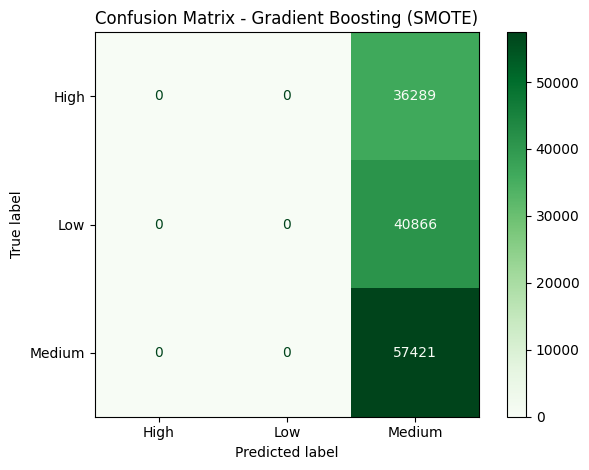


Confusion Matrix:
[[    0     0 36289]
 [    0     0 40866]
 [    0     0 57421]]

Labels order: ['High' 'Low' 'Medium']


In [ ]:
from sklearn.preprocessing import LabelEncoder
from imblearn.over_sampling import SMOTE
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Encode labels before SMOTE
le = LabelEncoder()
y_train_encoded = le.fit_transform(y_train)

# Generate synthetic samples
smote = SMOTE(random_state=42)
X_res, y_res = smote.fit_resample(X_train, y_train_encoded)

# Train Gradient Boosting on resampled data
gb_smote = GradientBoostingClassifier(random_state=42,
                                n_estimators=200,
                                learning_rate=0.05,
                                max_depth=3,
                                subsample=0.8,
                                min_samples_split=5,
                                min_samples_leaf=2 )
gb_smote.fit(X_res, y_res)

# Predict and decode back to original labels
y_pred_encoded = gb_smote.predict(X_test)
y_pred_gb = le.inverse_transform(y_pred_encoded)

# Evaluate
print(classification_report(y_test, y_pred_gb))

# Generate confusion matrix
cm = confusion_matrix(y_test, y_pred_gb)

# Display confusion matrix
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=le.classes_)
disp.plot(cmap='Greens')
plt.title('Confusion Matrix - Gradient Boosting (SMOTE)')
plt.tight_layout()
plt.show()

# Print the matrix
print("\nConfusion Matrix:")
print(cm)
print("\nLabels order:", le.classes_)

XGBoost

In [ ]:
from sklearn.utils.class_weight import compute_sample_weight
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split
from xgboost import XGBClassifier

# Encode labels
label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y)

# Train–test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y_encoded,
    test_size=0.2,
    random_state=42,
    stratify=y_encoded  # keeps class proportions consistent
)

# Scale features (fit only on train)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Train XGBoost WITHOUT SMOTE
xgb_clf = XGBClassifier(
    # Core complexity
    n_estimators=300,        # more trees, smaller learning_rate
    learning_rate=0.05,      # safer than 0.1, reduces overfitting
    max_depth=4,             # shallow-ish trees work well on tabular data
    min_child_weight=3,      # prevents overly specific splits

    # Subsampling for regularization
    subsample=0.8,           # row subsampling
    colsample_bytree=0.8,    # feature subsampling


    # Multi-class setup
    eval_metric='mlogloss',      # you already use this
    num_class=3,                 # Low / Medium / High

    # Housekeeping
    random_state=42,
)

# Fit model on original training data
xgb_clf.fit(
    X_train_scaled, y_train,
    eval_set=[(X_train_scaled, y_train), (X_test_scaled, y_test)],
    verbose=False
)

# Retrieve evaluation results
evals_result = xgb_clf.evals_result()


In [ ]:
from sklearn.utils.class_weight import compute_sample_weight
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split
from xgboost import XGBClassifier
from imblearn.over_sampling import SMOTE  # NEW

# Encode labels
label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y)

# Train–test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y_encoded,
    test_size=0.2,
    random_state=42,
    stratify=y_encoded  # optional but usually good for imbalance
)

# Scale features (fit only on train)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Apply SMOTE **only on the training set**
smote = SMOTE(random_state=42)
X_train_res, y_train_res = smote.fit_resample(X_train_scaled, y_train)

# NOTE: After SMOTE, classes are (mostly) balanced,
# so scale_pos_weight is usually not needed.
xgb_smote = XGBClassifier(
    # Core complexity
    n_estimators=300,        # more trees, smaller learning_rate
    learning_rate=0.05,      # safer than 0.1, reduces overfitting
    max_depth=4,             # shallow-ish trees work well on tabular data
    min_child_weight=3,      # prevents overly specific splits

    # Subsampling for regularization
    subsample=0.8,           # row subsampling
    colsample_bytree=0.8,    # feature subsampling


    # Multi-class setup
    eval_metric='mlogloss',      # you already use this
    num_class=3,                 # Low / Medium / High

    # Housekeeping
    random_state=42,
)

# Fit model on the resampled training data
xgb_smote.fit(
    X_train_res, y_train_res,
    eval_set=[(X_train_res, y_train_res), (X_test_scaled, y_test)],
    verbose=False
)

# Retrieve evaluation results
evals_result = xgb_smote.evals_result()


## Script

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(



Random Forest (Pre-Smote) Classification Report:

              precision    recall  f1-score   support

           0       0.28      0.10      0.15     36401
           1       0.31      0.20      0.24     40805
           2       0.43      0.70      0.53     57370

    accuracy                           0.39    134576
   macro avg       0.34      0.33      0.31    134576
weighted avg       0.35      0.39      0.34    134576



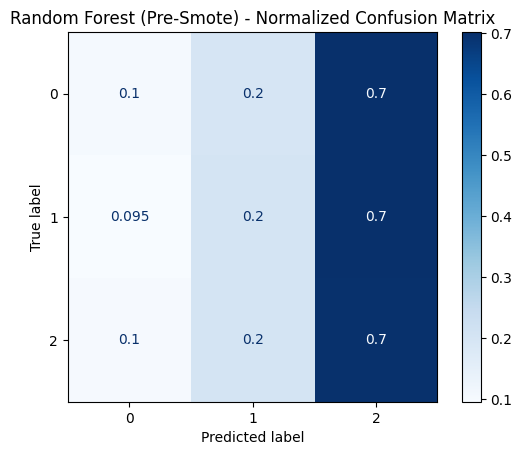

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(



Random Forest (Post-Smote) Classification Report:

              precision    recall  f1-score   support

           0       0.28      0.21      0.24     36401
           1       0.29      0.15      0.20     40805
           2       0.43      0.65      0.51     57370

    accuracy                           0.38    134576
   macro avg       0.34      0.34      0.32    134576
weighted avg       0.35      0.38      0.34    134576



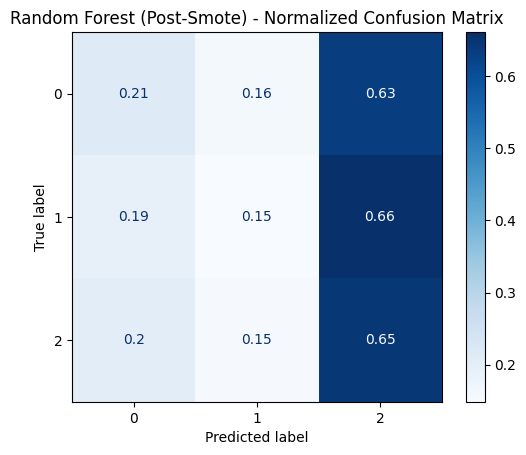

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but GradientBoostingClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but GradientBoostingClassifier was fitted with feature names
  warnings.warn(



Gradient Boosting (Pre-Smote) Classification Report:

              precision    recall  f1-score   support

           0       0.00      0.00      0.00     36401
           1       0.00      0.00      0.00     40805
           2       0.43      1.00      0.60     57370

    accuracy                           0.43    134576
   macro avg       0.14      0.33      0.20    134576
weighted avg       0.18      0.43      0.25    134576



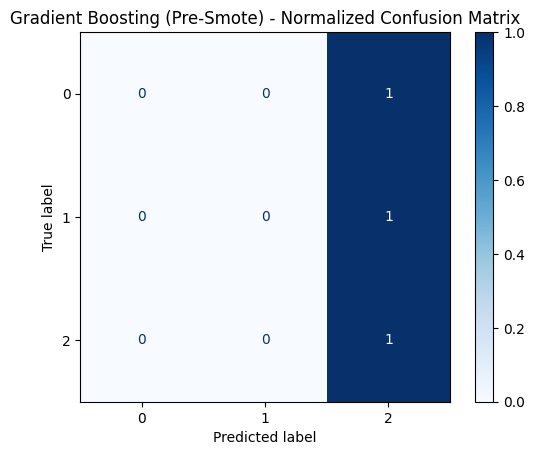

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but GradientBoostingClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but GradientBoostingClassifier was fitted with feature names
  warnings.warn(



Gradient Boosting (Post-Smote) Classification Report:

              precision    recall  f1-score   support

           0       0.00      0.00      0.00     36401
           1       0.00      0.00      0.00     40805
           2       0.43      1.00      0.60     57370

    accuracy                           0.43    134576
   macro avg       0.14      0.33      0.20    134576
weighted avg       0.18      0.43      0.25    134576



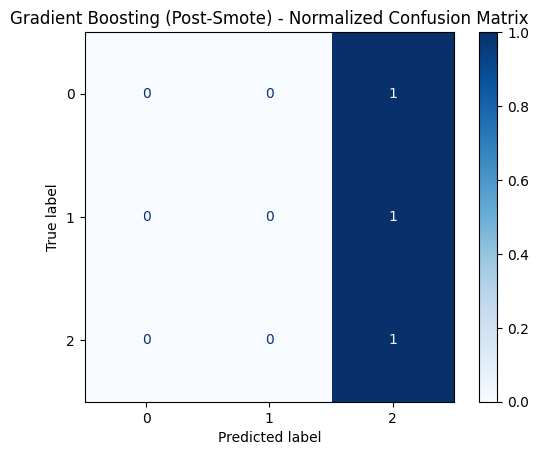


XGBoost (Pre-Smote) Classification Report:

              precision    recall  f1-score   support

           0       0.50      0.00      0.00     36401
           1       0.23      0.00      0.00     40805
           2       0.43      1.00      0.60     57370

    accuracy                           0.43    134576
   macro avg       0.39      0.33      0.20    134576
weighted avg       0.39      0.43      0.26    134576



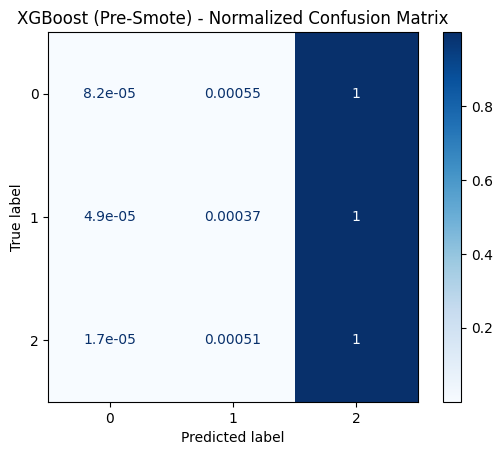


XGBoost (Post-Smote) Classification Report:

              precision    recall  f1-score   support

           0       0.28      0.29      0.29     36401
           1       0.32      0.30      0.31     40805
           2       0.43      0.44      0.43     57370

    accuracy                           0.36    134576
   macro avg       0.34      0.34      0.34    134576
weighted avg       0.35      0.36      0.35    134576



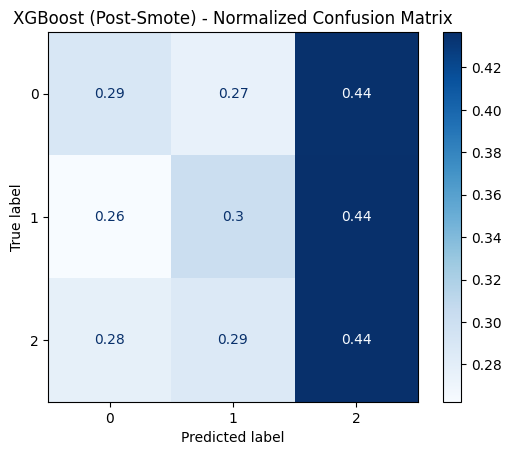


Model Comparison Summary:
                            Model  Accuracy  Precision (Weighted)  \
0       Random Forest (Pre-Smote)  0.386614              0.349474   
1      Random Forest (Post-Smote)  0.377296              0.347829   
2   Gradient Boosting (Pre-Smote)  0.426302              0.181733   
3  Gradient Boosting (Post-Smote)  0.426302              0.181733   
4             XGBoost (Pre-Smote)  0.426213              0.388041   
5            XGBoost (Post-Smote)  0.355509              0.354594   

   Recall (Weighted)  F1 (Weighted)  Precision (Macro)  Recall (Macro)  \
0           0.386614       0.339816           0.336702        0.334354   
1           0.377296       0.344219           0.335044        0.335084   
2           0.426302       0.254831           0.142101        0.333333   
3           0.426302       0.254831           0.142101        0.333333   
4           0.426213       0.255058           0.386892        0.333309   
5           0.355509       0.354954          

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, ConfusionMatrixDisplay, classification_report,
    log_loss
)

# ------------------------------
# Assume your models are already trained:
# rf_pre, rf_post, gb_pre, gb_post, xgb_clf
# X_test_scaled, y_test
# ------------------------------

# Keep y_test as a proper Series with original dtype (e.g., 0/1/2)
y_test_ser = pd.Series(y_test)

models = {
    "Random Forest (Pre-Smote)": rf,
    "Random Forest (Post-Smote)": rf_smote,
    "Gradient Boosting (Pre-Smote)": gb,
    "Gradient Boosting (Post-Smote)": gb_smote,
    "XGBoost (Pre-Smote)": xgb_clf,
    "XGBoost (Post-Smote)": xgb_smote
}

results = []

for name, model in models.items():
    # Predictions (class labels)
    y_pred = model.predict(X_test_scaled)

    # Probabilities for log-loss
    y_proba = model.predict_proba(X_test_scaled)

    # Metrics for imbalanced classes
    acc = accuracy_score(y_test_ser, y_pred)
    precision_w = precision_score(y_test_ser, y_pred, average='weighted', zero_division=0)
    recall_w = recall_score(y_test_ser, y_pred, average='weighted', zero_division=0)
    f1_w = f1_score(y_test_ser, y_pred, average='weighted', zero_division=0)

    # Macro metrics to treat all classes equally
    precision_m = precision_score(y_test_ser, y_pred, average='macro', zero_division=0)
    recall_m = recall_score(y_test_ser, y_pred, average='macro', zero_division=0)
    f1_m = f1_score(y_test_ser, y_pred, average='macro', zero_division=0)

    # Log-loss (lower = better), using probabilities
    ll = log_loss(y_test_ser, y_proba, labels=model.classes_)

    results.append({
        "Model": name,
        "Accuracy": acc,
        "Precision (Weighted)": precision_w,
        "Recall (Weighted)": recall_w,
        "F1 (Weighted)": f1_w,
        "Precision (Macro)": precision_m,
        "Recall (Macro)": recall_m,
        "F1 (Macro)": f1_m,
        "Log Loss": ll
    })

    # Classification report (detailed per class)
    print(f"\n{name} Classification Report:\n")
    print(classification_report(y_test_ser, y_pred, zero_division=0))

    # Confusion matrix (normalized per true class)
    labels = sorted(y_test_ser.unique())
    cm = confusion_matrix(y_test_ser, y_pred, labels=labels, normalize='true')
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=labels)
    disp.plot(cmap="Blues")
    plt.title(f"{name} - Normalized Confusion Matrix")
    plt.show()

# ------------------------------
# Summary table
# ------------------------------
results_df = pd.DataFrame(results)
print("\nModel Comparison Summary:")
print(results_df)


In [ ]:
results_df

,Model,Accuracy,Precision (Weighted),Recall (Weighted),F1 (Weighted),Precision (Macro),Recall (Macro),F1 (Macro),Log Loss
0,Random Forest (Pre-Smote),0.386614,0.349474,0.386614,0.339816,0.336702,0.334354,0.307514,1.096198
1,Random Forest (Post-Smote),0.377296,0.347829,0.377296,0.344219,0.335044,0.335084,0.317748,1.094080
2,Gradient Boosting (Pre-Smote),0.426302,0.181733,0.426302,0.254831,0.142101,0.333333,0.199257,1.095923
3,Gradient Boosting (Post-Smote),0.426302,0.181733,0.426302,0.254831,0.142101,0.333333,0.199257,1.082015
4,XGBoost (Pre-Smote),0.426213,0.388041,0.426213,0.255058,0.386892,0.333309,0.199526,1.078226
5,XGBoost (Post-Smote),0.355509,0.354594,0.355509,0.354954,0.342314,0.342162,0.342137,1.094280


In [ ]:
results_df

,Model,Accuracy,Precision (Weighted),Recall (Weighted),F1 (Weighted),Precision (Macro),Recall (Macro),F1 (Macro),Log Loss
0,Random Forest (Pre-Smote),0.386614,0.349474,0.386614,0.339816,0.336702,0.334354,0.307514,1.096198
1,Random Forest (Post-Smote),0.377296,0.347829,0.377296,0.344219,0.335044,0.335084,0.317748,1.094080
2,Gradient Boosting (Pre-Smote),0.426302,0.181733,0.426302,0.254831,0.142101,0.333333,0.199257,1.095923
3,Gradient Boosting (Post-Smote),0.426302,0.181733,0.426302,0.254831,0.142101,0.333333,0.199257,1.082015
4,XGBoost (Pre-Smote),0.426213,0.388041,0.426213,0.255058,0.386892,0.333309,0.199526,1.078226
5,XGBoost (Post-Smote),0.355509,0.354594,0.355509,0.354954,0.342314,0.342162,0.342137,1.094280


In [ ]:
for name, model in models.items():
    print("\n---", name, "---")
    print(model.predict_proba(X_test_scaled)[:5])


--- Random Forest (Pre-Smote) ---


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(


[[0.37596017 0.30109412 0.32294571]
 [0.31112838 0.31443915 0.37443247]
 [0.32049586 0.31779203 0.36171212]
 [0.30935414 0.36824562 0.32240024]
 [0.33245511 0.36069777 0.30684712]]

--- Random Forest (Post-Smote) ---


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(


[[0.3917427  0.25330668 0.35495062]
 [0.26276924 0.31695955 0.42027121]
 [0.31415744 0.29681347 0.38902909]
 [0.31798235 0.28248517 0.39953248]
 [0.33889146 0.39947961 0.26162893]]

--- Gradient Boosting (Pre-Smote) ---


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but GradientBoostingClassifier was fitted with feature names
  warnings.warn(


[[0.24358328 0.27560678 0.48080994]
 [0.20360965 0.25113013 0.54526022]
 [0.2414306  0.28815914 0.47041026]
 [0.1941824  0.3297965  0.47602111]
 [0.23425014 0.23104372 0.53470614]]

--- Gradient Boosting (Post-Smote) ---


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but GradientBoostingClassifier was fitted with feature names
  warnings.warn(


[[0.30230057 0.31430757 0.38339186]
 [0.28989334 0.32480007 0.3853066 ]
 [0.30425493 0.30974102 0.38600406]
 [0.25778868 0.35706407 0.38514724]
 [0.30379666 0.31347294 0.3827304 ]]

--- XGBoost (Pre-Smote) ---
[[0.26781175 0.29574218 0.43644607]
 [0.26313636 0.314177   0.4226867 ]
 [0.27773878 0.29270455 0.4295567 ]
 [0.22769366 0.33929384 0.43301246]
 [0.27051705 0.31014532 0.4193376 ]]

--- XGBoost (Post-Smote) ---
[[0.32840753 0.3237911  0.3478014 ]
 [0.31471476 0.33672303 0.3485622 ]
 [0.33544177 0.31972814 0.34483013]
 [0.2852225  0.3813692  0.3334083 ]
 [0.33792242 0.32871428 0.33336326]]


In [ ]:
print(pd.Series(y_train).unique())
print(pd.Series(y_test).unique())

[0 1 2]
[0 1 2]


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but GradientBoostingClassifier was fitted with feature names
  warnings.warn(


X_test_df shape: (134576, 18)
X_background shape: (300, 18)
X_to_explain shape: (100, 18)


  0%|          | 0/100 [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but GradientBoostingClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but GradientBoostingClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but GradientBoostingClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but GradientBoostingClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but GradientBoostingClassifier was fitted with feature names
  warni

shap_values shape: (100, 18)


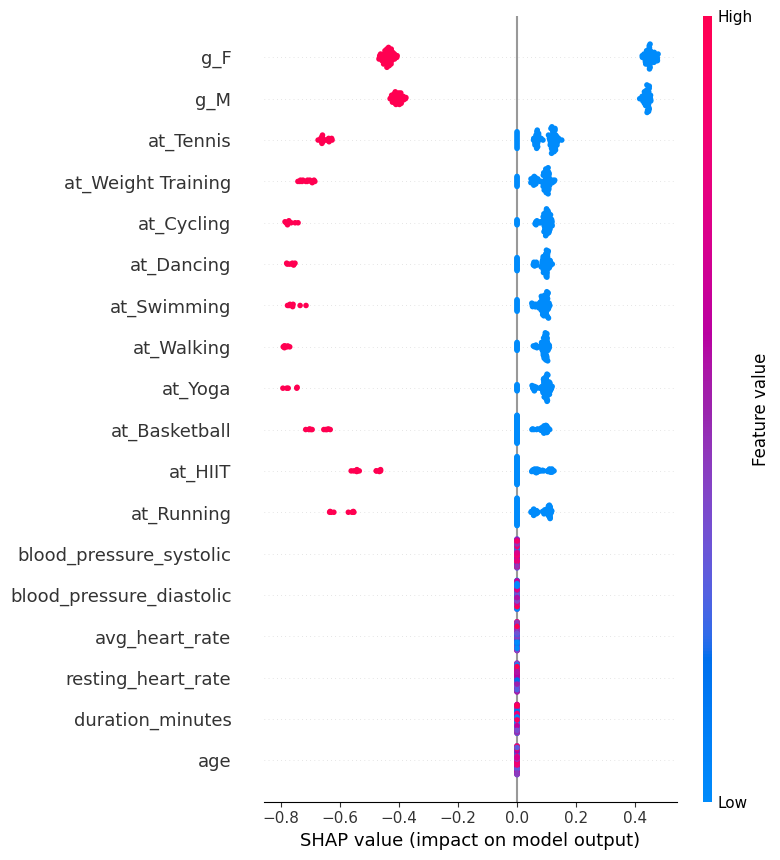

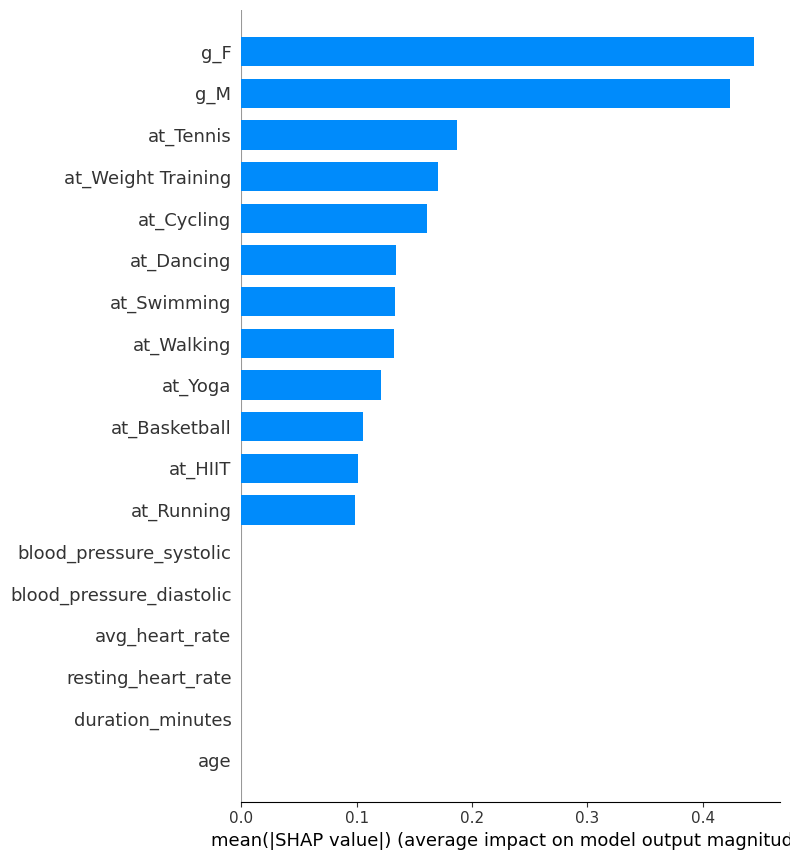

In [ ]:
import numpy as np
import pandas as pd
import shap

shap.initjs()

# ---------------------------------------------------
# 1. Build X_test_df with correct feature names
# ---------------------------------------------------
n_samples_test, n_features_test = X_test_scaled.shape

# If you still have X as a DataFrame with columns from training, reuse those
try:
    if isinstance(X, pd.DataFrame) and X.shape[1] == n_features_test:
        feature_names = list(X.columns)
    else:
        feature_names = [f"feature_{i}" for i in range(n_features_test)]
except NameError:
    feature_names = [f"feature_{i}" for i in range(n_features_test)]

X_test_df = pd.DataFrame(X_test_scaled, columns=feature_names)
print("X_test_df shape:", X_test_df.shape)  # should be (N, 19)

# ---------------------------------------------------
# 2. Background + samples for Kernel SHAP
# ---------------------------------------------------
X_background = X_test_df.sample(min(300, len(X_test_df)), random_state=42)
X_to_explain = X_test_df.sample(min(100, len(X_test_df)), random_state=42)

print("X_background shape:", X_background.shape)
print("X_to_explain shape:", X_to_explain.shape)

# ---------------------------------------------------
# 3. KernelExplainer on PREDICTIONS (not predict_proba)
#    -> gives (n_samples, n_features) shap values
# ---------------------------------------------------
explainer = shap.KernelExplainer(
    lambda X: gb_smote.predict(X),   # explain the predicted class decision
    X_background
)

shap_values = explainer.shap_values(X_to_explain)  # expected shape: (n_samples, n_features)
shap_values = np.array(shap_values)

print("shap_values shape:", shap_values.shape)

# Sanity check: shapes must match
assert shap_values.shape == X_to_explain.shape, (
    f"Shape mismatch: shap_values {shap_values.shape} vs X_to_explain {X_to_explain.shape}"
)

# ---------------------------------------------------
# 4. SHAP summary plots
# ---------------------------------------------------
shap.summary_plot(
    shap_values,
    X_to_explain,
    feature_names=X_to_explain.columns,
    show=True
)

shap.summary_plot(
    shap_values,
    X_to_explain,
    feature_names=X_to_explain.columns,
    plot_type="bar",
    show=True
)


X_test_df shape: (134576, 18)
X_background shape: (300, 18)
X_to_explain shape: (100, 18)


  0%|          | 0/100 [00:00<?, ?it/s]

shap_values shape: (100, 18)


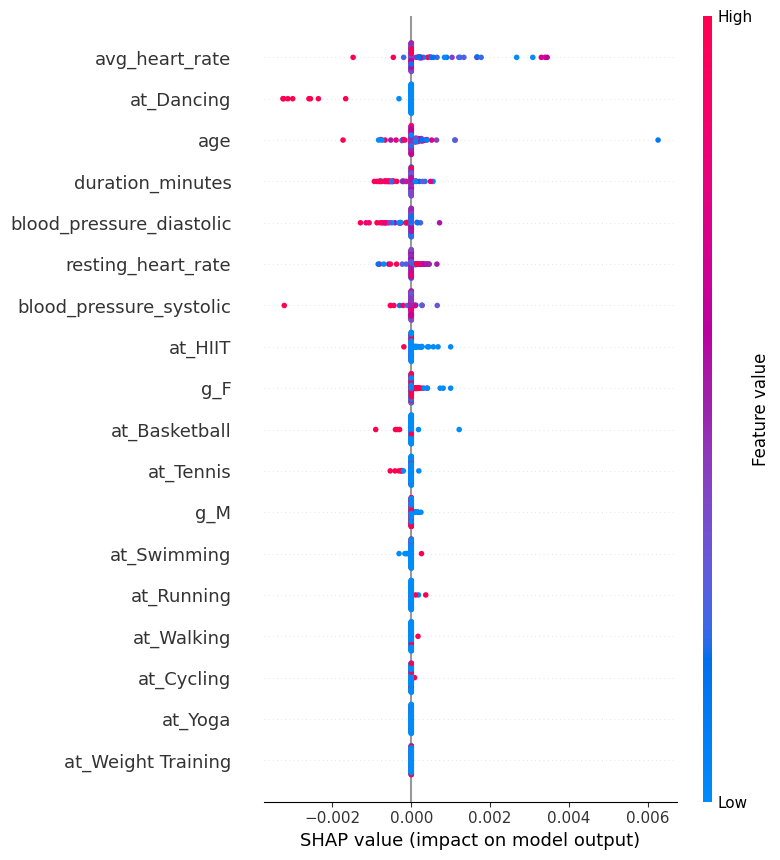

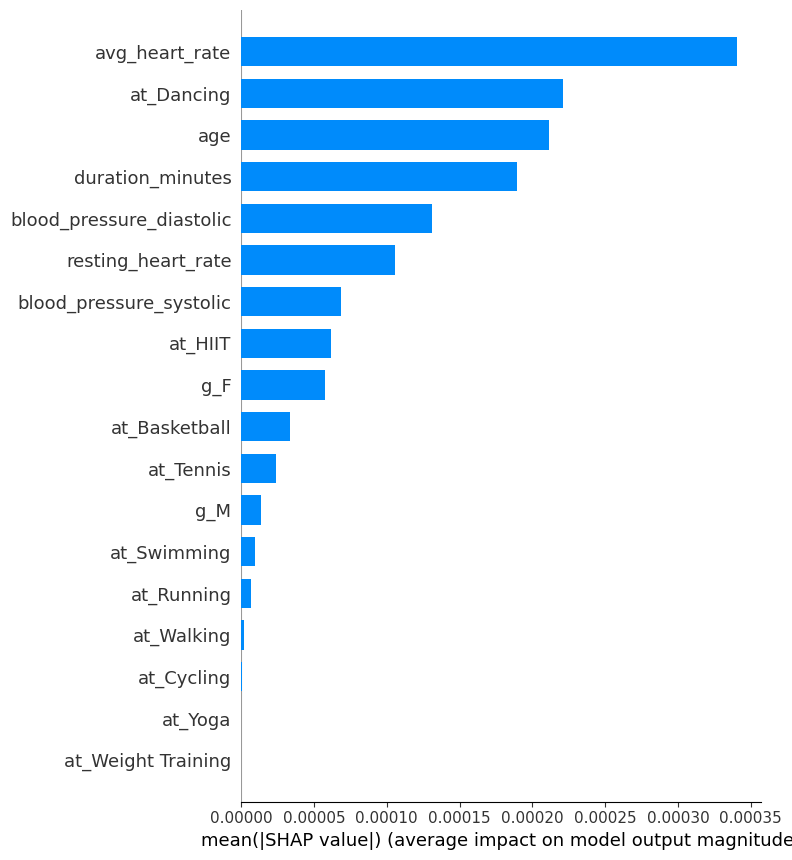

In [ ]:
import numpy as np
import pandas as pd
import shap

shap.initjs()

# ---------------------------------------------------
# 1. Build X_test_df with correct feature names
# ---------------------------------------------------
n_samples_test, n_features_test = X_test_scaled.shape

# If you still have X as a DataFrame with columns from training, reuse those
try:
    if isinstance(X, pd.DataFrame) and X.shape[1] == n_features_test:
        feature_names = list(X.columns)
    else:
        feature_names = [f"feature_{i}" for i in range(n_features_test)]
except NameError:
    feature_names = [f"feature_{i}" for i in range(n_features_test)]

X_test_df = pd.DataFrame(X_test_scaled, columns=feature_names)
print("X_test_df shape:", X_test_df.shape)  # should be (N, 19)

# ---------------------------------------------------
# 2. Background + samples for Kernel SHAP
# ---------------------------------------------------
X_background = X_test_df.sample(min(300, len(X_test_df)), random_state=42)
X_to_explain = X_test_df.sample(min(100, len(X_test_df)), random_state=42)

print("X_background shape:", X_background.shape)
print("X_to_explain shape:", X_to_explain.shape)

# ---------------------------------------------------
# 3. KernelExplainer on PREDICTIONS (not predict_proba)
#    -> gives (n_samples, n_features) shap values
# ---------------------------------------------------
explainer = shap.KernelExplainer(
    lambda X: xgb_clf.predict(X),   # explain the predicted class decision
    X_background
)

shap_values = explainer.shap_values(X_to_explain)  # expected shape: (n_samples, n_features)
shap_values = np.array(shap_values)

print("shap_values shape:", shap_values.shape)

# Sanity check: shapes must match
assert shap_values.shape == X_to_explain.shape, (
    f"Shape mismatch: shap_values {shap_values.shape} vs X_to_explain {X_to_explain.shape}"
)

# ---------------------------------------------------
# 4. SHAP summary plots
# ---------------------------------------------------
shap.summary_plot(
    shap_values,
    X_to_explain,
    feature_names=X_to_explain.columns,
    show=True
)

shap.summary_plot(
    shap_values,
    X_to_explain,
    feature_names=X_to_explain.columns,
    plot_type="bar",
    show=True
)


In [ ]:
import numpy as np
import pandas as pd

activity_cols = [
    "at_Basketball", "at_Cycling", "at_Dancing", "at_HIIT",
    "at_Running", "at_Swimming", "at_Tennis", "at_Walking",
    "at_Weight Training", "at_Yoga"
]


# assume classes_ = ['Low', 'Medium', 'High']
high_idx = list((model.classes_)).index(2)

def recommend_activity(user_row: pd.Series, model) -> str:
    # user_row is one row from df_encoded[X.columns]
    user_row = user_row.copy()

    best_activity = None
    best_high_prob = 1.0  # we want to MINIMIZE this

    for act in activity_cols:
        temp = user_row.copy()
        # zero out all activities
        temp[activity_cols] = 0
        # set this activity to 1
        temp[act] = 1

        proba = model.predict_proba([temp.values])[0]
        p_high = proba[high_idx]

        if p_high < best_high_prob:
            best_high_prob = p_high
            best_activity = act

    return best_activity, best_high_prob


In [ ]:
user = df_encoded[X.columns].iloc[893]   # example user
print(user)
rec_act, prob_high = recommend_activity(user, model)
print("Recommended activity:", rec_act, "Predicted P(high stress) =", prob_high)

age                         37.751978
duration_minutes                   72
at_Basketball                   False
at_Cycling                      False
at_Dancing                      False
at_HIIT                          True
at_Running                      False
at_Swimming                     False
at_Tennis                       False
at_Walking                      False
at_Weight Training              False
at_Yoga                         False
g_F                              True
g_M                             False
avg_heart_rate                    122
resting_heart_rate               60.7
blood_pressure_systolic         130.1
blood_pressure_diastolic         69.3
Name: 893, dtype: object
Recommended activity: at_Basketball Predicted P(high stress) = 0.4868961
